# Exercice 1

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
import numpy as np

   speed  dist
0      4     2
1      4    10
2      7     4
3      7    22
4      8    16


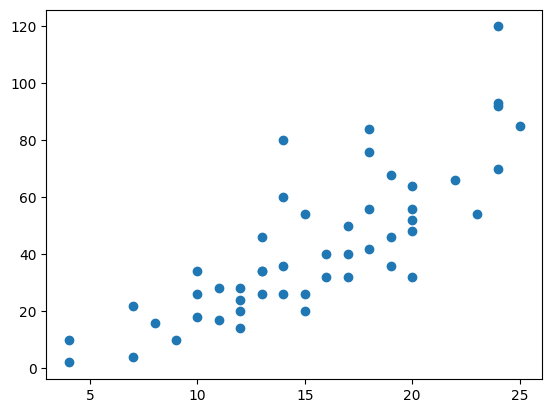

In [6]:
# Load DataFrame
df = pd.read_csv('cars.csv')
print(df.head())

# Simple scatter plot
plt.scatter(df['speed'], df['dist']);

In [3]:
model_linear = smf.ols(formula = 'dist ~ speed', data = df).fit()
print(model_linear.summary())
model_quadratic = smf.ols(formula = 'dist ~ speed + I(speed**2)', data = df).fit()
print(model_quadratic.summary())

                            OLS Regression Results                            
Dep. Variable:                   dist   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     89.57
Date:                Tue, 28 May 2024   Prob (F-statistic):           1.49e-12
Time:                        11:50:45   Log-Likelihood:                -206.58
No. Observations:                  50   AIC:                             417.2
Df Residuals:                      48   BIC:                             421.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -17.5791      6.758     -2.601      0.0

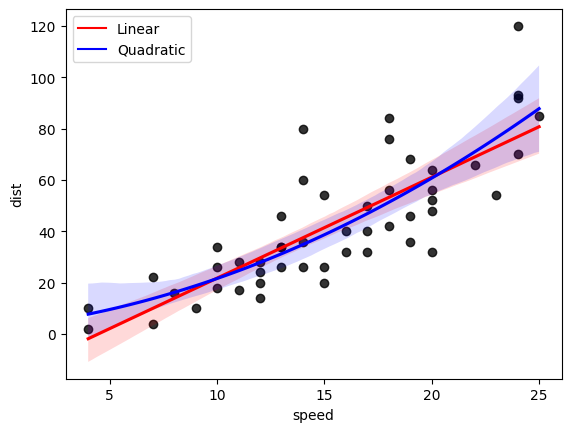

In [4]:
import matplotlib.lines as mlines
sns.regplot(x = 'speed',
            y = 'dist',
            data=df,
            scatter = True,
            color = 'red',
            scatter_kws = {'color': 'black'},
            label = 'Linear')
sns.regplot(x = 'speed',
            y = 'dist',
            data = df,
            order = 2, # !!!
            color = 'blue',
            scatter = False,
            label = 'Quadratic')
linear_line = mlines.Line2D([], [], color = 'red', label = 'Linear')
quadratic_line = mlines.Line2D([], [], color = 'blue', label = 'Quadratic')
plt.legend(handles = [linear_line, quadratic_line])
plt.show()

# Exercice 2

In [9]:
# Load DataFrame
df = pd.read_csv('patient.csv')
print(df.head())

   age        BMI  smoking_status  genetic_risk  diabetes
0   64  29.722920               0             2         0
1   67  35.121296               0             3         0
2   20  39.112930               0             3         0
3   23  21.022390               0             2         0
4   23  20.800589               0             0         1


In [19]:
# Model
model = smf.glm('diabetes ~ age + BMI + smoking_status + genetic_risk',
                data = df,
                family = sm.families.Binomial()).fit()
print(model.summary())
print('AIC:', np.round(model.aic, 2))
print('BIC:', np.round(model.bic_llf, 2))

                 Generalized Linear Model Regression Results                  
Dep. Variable:               diabetes   No. Observations:                 1000
Model:                            GLM   Df Residuals:                      995
Model Family:                Binomial   Df Model:                            4
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -379.99
Date:                Tue, 28 May 2024   Deviance:                       759.98
Time:                        13:01:27   Pearson chi2:                 1.00e+03
No. Iterations:                     5   Pseudo R-squ. (CS):           0.001306
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -1.6503      0.564     -2.

In [ ]:
df['predicted_prob'] = model.predict(df)
df.head()

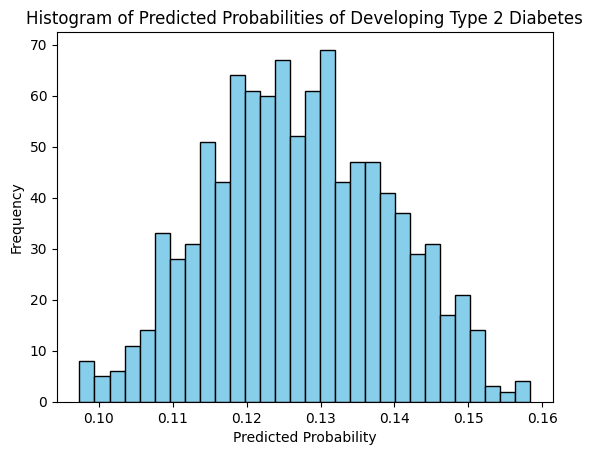


Coefficients:
 Intercept        -1.650327
age              -0.004783
BMI               0.000786
smoking_status    0.050700
genetic_risk     -0.052951
dtype: float64

Odds Ratios:
 Intercept         0.191987
age               0.995228
BMI               1.000786
smoking_status    1.052008
genetic_risk      0.948427
dtype: float64


In [12]:
plt.hist(df['predicted_prob'],
         bins = 30,
         color = 'skyblue',
         edgecolor = 'black')
plt.title('Histogram of Predicted Probabilities of Developing Type 2 Diabetes')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.show()

# Extracting the coefficients to interpret the impact of each predictor
print("\nCoefficients:\n", model.params)

# Examining the odds ratios to understand the impact of predictors better
odds_ratios = np.exp(model.params)
print("\nOdds Ratios:\n", odds_ratios)